In [1]:
# 预处理 Chen-2019 RNA

In [3]:
import anndata as ad
import networkx as nx
import scanpy as sc
import scglue
from matplotlib import rcParams

/home/dhy/anaconda3/lib/python3.11/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [4]:
# scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

In [5]:
rna = ad.read_h5ad("/nfs/hb236/dhy/sxSNF_2.0/code/datasets/Chen-2019-RNA.h5ad")
rna

AnnData object with n_obs × n_vars = 9190 × 28930
    obs: 'domain', 'protocol', 'dataset', 'cell_type'
    var: 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_type', 'mgi_id', 'havana_gene', 'tag', 'genome', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [6]:
rna.X, rna.X.data

(<Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 8633857 stored elements and shape (9190, 28930)>,
 array([1., 1., 1., ..., 3., 1., 1.], dtype=float32))

In [7]:
rna.layers["counts"] = rna.X.copy()

In [8]:
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor="seurat_v3")

In [9]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.tl.pca(rna, n_comps=100, svd_solver="auto")

/home/dhy/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/dhy/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


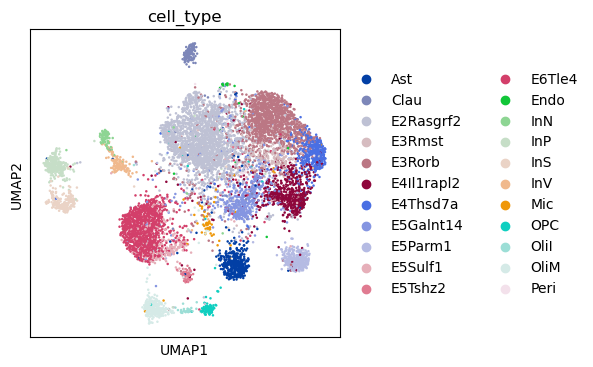

In [10]:
sc.pp.neighbors(rna, metric="cosine")
sc.tl.umap(rna)
sc.pl.umap(rna, color="cell_type")

In [11]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score
import numpy as np
rna

# 提取真实细胞类型标签
true_labels = rna.obs['cell_type'].values

# 使用 Leiden 算法进行聚类（基于邻居图）
sc.tl.leiden(rna, key_added='leiden')

# 获取聚类标签
cluster_labels = rna.obs['leiden'].values

# 计算聚类指标
ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)

# 打印结果
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"AMI: {ami:.4f}")


ARI: 0.5873
NMI: 0.6741
AMI: 0.6701


In [12]:
# 预处理 Chen-2019 ATAC

In [13]:
atac = ad.read_h5ad("/nfs/hb236/dhy/sxSNF_2.0/code/datasets/Chen-2019-ATAC.h5ad")
atac

AnnData object with n_obs × n_vars = 9190 × 241757
    obs: 'domain', 'protocol', 'dataset', 'cell_type'
    var: 'chrom', 'chromStart', 'chromEnd', 'genome', 'n_counts'

In [14]:
atac.X, atac.X.data

(<Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 22575391 stored elements and shape (9190, 241757)>,
 array([2., 1., 1., ..., 1., 1., 1.], dtype=float32))

In [15]:
scglue.data.lsi(atac, n_components=100, n_iter=15)

In [16]:
sc.pp.neighbors(atac, use_rep="X_lsi", metric="cosine")
sc.tl.umap(atac)

/home/dhy/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/dhy/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


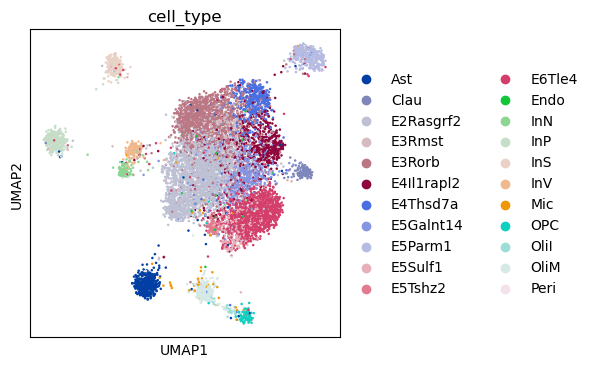

In [17]:
sc.pl.umap(atac, color="cell_type")

In [18]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score
import scanpy as sc
atac

# Perform Leiden clustering on LSI embedding
sc.pp.neighbors(atac, use_rep='X_lsi', key_added='leiden_neighbors')
sc.tl.leiden(atac, neighbors_key='leiden_neighbors', key_added='leiden')

# Compute clustering metrics using cell_type as ground truth
true_labels = atac.obs['cell_type']
pred_labels = atac.obs['leiden']

ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
ami = adjusted_mutual_info_score(true_labels, pred_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"AMI: {ami:.4f}")


ARI: 0.5421
NMI: 0.6180
AMI: 0.6155


In [19]:
# 数据预处理结束

In [20]:
rna

AnnData object with n_obs × n_vars = 9190 × 28930
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'leiden'
    var: 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_type', 'mgi_id', 'havana_gene', 'tag', 'genome', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'cell_type_colors', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [21]:
atac

AnnData object with n_obs × n_vars = 9190 × 241757
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'leiden'
    var: 'chrom', 'chromStart', 'chromEnd', 'genome', 'n_counts'
    uns: 'neighbors', 'umap', 'cell_type_colors', 'leiden_neighbors', 'leiden'
    obsm: 'X_lsi', 'X_umap'
    obsp: 'distances', 'connectivities', 'leiden_neighbors_distances', 'leiden_neighbors_connectivities'

In [22]:
ok = (rna.obs_names == atac.obs_names).all()
print("obs_names aligned:", ok)
if not ok:
    raise ValueError("RNA/ATAC cell order mismatch")


obs_names aligned: True


In [23]:
# Extract low-dimensional representations
rna_pca  = rna.obsm["X_pca"]            # shape (n_cells, n_pcs)
atac_lsi = atac.obsm["X_lsi"]           # shape (n_cells, n_components)

# Use cell-type annotation from RNA as ground-truth labels
labels = rna.obs["cell_type"].astype("category").cat.codes.values

In [ ]:
# Geometry-anchored SNF

# 增强GNN复杂度

# 调小学习率

# 增加 epoch

In [46]:
# ============================================================
# sxSNF-like pipeline with stage-wise clustering evaluation
# SNF IMPROVEMENT (Scheme A): Geometry-anchored SNF
#   Pi <- (1-alpha) * Normalize(Si @ P_others @ Si^T) + alpha * P0i
# GNN UPGRADE: Deep GCNII-style encoder (stable depth)
# ============================================================

import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
)
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False
    from sklearn.manifold import TSNE

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception:
    HAS_PANDAS = False


# -----------------------------
# 0) Utilities
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def knn_affinity(X, k=20, metric="cosine", mode="cos", sigma=None, sym=True):
    n = X.shape[0]
    nnbrs = NearestNeighbors(n_neighbors=min(k + 1, n), metric=metric)
    nnbrs.fit(X)
    dists, idx = nnbrs.kneighbors(X, return_distance=True)

    dists = dists[:, 1:]
    idx = idx[:, 1:]

    W = np.zeros((n, n), dtype=np.float32)

    if mode == "heat":
        if sigma is None:
            sigma = np.median(dists)
            sigma = max(float(sigma), 1e-6)
        denom = 2.0 * (sigma ** 2)
        weights = np.exp(-(dists ** 2) / denom).astype(np.float32)
    elif mode == "cos":
        weights = (1.0 - dists).astype(np.float32)
        weights = np.clip(weights, 0.0, 1.0)
    else:
        raise ValueError("mode must be 'heat' or 'cos'")

    for i in range(n):
        W[i, idx[i]] = weights[i]

    if sym:
        W = np.maximum(W, W.T)

    np.fill_diagonal(W, 0.0)
    return W


def knn_affinity_local_scaling(X, k=20, metric="cosine", sym=True, eps=1e-12):
    """
    Self-tuning (local scaling) affinity:
    W_ij = exp( - d_ij^2 / (sigma_i * sigma_j + eps) )
    where sigma_i = distance to k-th neighbor of i
    """
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    k_eff = min(k + 1, n)
    nnbrs = NearestNeighbors(n_neighbors=k_eff, metric=metric)
    nnbrs.fit(X)
    dists, idx = nnbrs.kneighbors(X, return_distance=True)

    dists = dists[:, 1:]
    idx = idx[:, 1:]

    sigma = dists[:, -1].astype(np.float32)
    sigma = np.maximum(sigma, 1e-6)

    W = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        j = idx[i]
        dij = dists[i].astype(np.float32)
        denom = (sigma[i] * sigma[j] + eps)
        w = np.exp(-(dij ** 2) / denom).astype(np.float32)
        W[i, j] = w

    if sym:
        W = np.maximum(W, W.T)
    np.fill_diagonal(W, 0.0)
    return W


def knn_sparsify_dense(W, k=20):
    n = W.shape[0]
    W2 = np.zeros_like(W)
    for i in range(n):
        row = W[i]
        nn_idx = np.argpartition(row, -k)[-k:] if k < n else np.arange(n)
        W2[i, nn_idx] = row[nn_idx]
    W2 = np.maximum(W2, W2.T)
    np.fill_diagonal(W2, 0.0)
    return W2


def _row_normalize(W, eps=1e-12):
    W = W.astype(np.float32, copy=False)
    rs = W.sum(axis=1, keepdims=True)
    return (W / (rs + eps)).astype(np.float32)


# -----------------------------
# 1) Geometry-anchored SNF (Scheme A)
# -----------------------------
def snf_fusion_dense_anchored(W_list, k=20, t=20, alpha=0.2, eps=1e-12):
    """
    Geometry-anchored SNF:
      - Build P0_i: row-normalized full graph from W_i (random walk)
      - Build S_i: kNN-sparsified + row-normalized
      - Iterate:
          P_i <- Normalize(S_i @ P_others @ S_i^T)
          P_i <- (1-alpha)*P_i + alpha*P0_i
          P_i <- row-normalize
      - Output: symmetric fused P
    """
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("alpha must be in [0,1].")

    m = len(W_list)
    n = W_list[0].shape[0]
    for W in W_list:
        assert W.shape == (n, n)

    P0_list = []
    S_list = []

    for W in W_list:
        W0 = np.asarray(W, dtype=np.float32).copy()
        np.fill_diagonal(W0, 0.0)
        W0 = np.maximum(W0, 0.0)

        P0 = _row_normalize(W0, eps=eps)
        P0_list.append(P0)

        S = knn_sparsify_dense(W0, k=k)
        S = _row_normalize(S, eps=eps)
        S_list.append(S)

    P_list = [p.copy() for p in P0_list]

    for _ in range(t):
        P_new = []
        P_bar = sum(P_list) / m

        for i in range(m):
            P_others = (m * P_bar - P_list[i]) / (m - 1)
            Pi = S_list[i] @ P_others @ S_list[i].T
            Pi = _row_normalize(Pi, eps=eps)

            Pi = (1.0 - alpha) * Pi + alpha * P0_list[i]
            Pi = _row_normalize(Pi, eps=eps)

            P_new.append(Pi.astype(np.float32))

        P_list = P_new

    P_fused = sum(P_list) / m
    P_fused = 0.5 * (P_fused + P_fused.T)
    np.fill_diagonal(P_fused, 0.0)
    return P_fused.astype(np.float32)


# -----------------------------
# 2) Torch sparse helpers
# -----------------------------
def dense_to_torch_sparse(A, device):
    A = np.asarray(A)
    rows, cols = np.nonzero(A)
    vals = A[rows, cols].astype(np.float32)
    idx = torch.tensor(np.vstack([rows, cols]), dtype=torch.long, device=device)
    val = torch.tensor(vals, dtype=torch.float32, device=device)
    n = A.shape[0]
    return torch.sparse_coo_tensor(idx, val, (n, n), device=device).coalesce()


def normalize_adj_torch_sparse(adj):
    n = adj.shape[0]
    eye_idx = torch.arange(n, device=adj.device)
    eye = torch.sparse_coo_tensor(
        torch.stack([eye_idx, eye_idx], dim=0),
        torch.ones(n, device=adj.device),
        (n, n),
        device=adj.device
    ).coalesce()

    A = (adj + eye).coalesce()
    deg = torch.sparse.sum(A, dim=1).to_dense()
    deg_inv_sqrt = torch.pow(deg + 1e-12, -0.5)

    idx = A.indices()
    val = A.values()
    val_norm = val * deg_inv_sqrt[idx[0]] * deg_inv_sqrt[idx[1]]
    return torch.sparse_coo_tensor(idx, val_norm, A.shape, device=A.device).coalesce()


# -----------------------------
# 3) Labels / metrics
# -----------------------------
def _labels_to_int(labels):
    lab = np.asarray(labels)
    if np.issubdtype(lab.dtype, np.number):
        return lab.astype(np.int32)
    if HAS_PANDAS:
        return pd.Categorical(lab).codes.astype(np.int32)
    uniq = {v: i for i, v in enumerate(sorted(set(lab.tolist())))}
    return np.array([uniq[v] for v in lab.tolist()], dtype=np.int32)


def clustering_metrics(true_labels_int, pred_labels_int):
    return {
        "ARI": float(adjusted_rand_score(true_labels_int, pred_labels_int)),
        "NMI": float(normalized_mutual_info_score(true_labels_int, pred_labels_int)),
        "AMI": float(adjusted_mutual_info_score(true_labels_int, pred_labels_int)),
    }


def leiden_cluster_from_embedding(Z, n_neighbors=15, resolution=1.0, seed=42):
    try:
        import scanpy as sc
        import anndata as ad
        adata = ad.AnnData(X=Z.astype(np.float32))
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep="X", random_state=seed)
        sc.tl.leiden(adata, resolution=resolution, random_state=seed, key_added="leiden")
        return adata.obs["leiden"].astype("category").cat.codes.to_numpy().astype(np.int32)
    except Exception as e:
        print(f"[WARN] Leiden(embedding) failed ({e}). Fallback KMeans.")
        km = KMeans(n_clusters=10, n_init=20, random_state=seed)
        return km.fit_predict(Z).astype(np.int32)


def leiden_cluster_from_affinity(W, resolution=1.0, seed=42, fallback_n_clusters=None):
    W = np.asarray(W).astype(np.float32)
    n = W.shape[0]
    np.fill_diagonal(W, 0.0)
    try:
        import scanpy as sc
        import anndata as ad
        import scipy.sparse as sp
        adata = ad.AnnData(X=np.zeros((n, 1), dtype=np.float32))
        adata.obsp["connectivities"] = sp.csr_matrix(W)
        adata.uns["neighbors"] = {"connectivities_key": "connectivities", "distances_key": None, "params": {}}
        sc.tl.leiden(adata, resolution=resolution, random_state=seed, key_added="leiden")
        return adata.obs["leiden"].astype("category").cat.codes.to_numpy().astype(np.int32)
    except Exception as e:
        print(f"[WARN] Leiden(affinity) failed ({e}). Fallback SpectralClustering.")
        if fallback_n_clusters is None:
            fallback_n_clusters = 10
        Wsym = 0.5 * (W + W.T)
        scm = SpectralClustering(
            n_clusters=int(fallback_n_clusters),
            affinity="precomputed",
            assign_labels="kmeans",
            random_state=seed,
        )
        return scm.fit_predict(Wsym).astype(np.int32)


def atac_only_eval_exact_scanpy(atac_adata, label_key="cell_type", n_neighbors=15, resolution=1.0):
    """
    EXACTLY matches user's code:
        sc.pp.neighbors(atac, use_rep='X_lsi', key_added='leiden_neighbors')
        sc.tl.leiden(atac, neighbors_key='leiden_neighbors', key_added='leiden')
    """
    import scanpy as sc

    adata = atac_adata.copy()
    sc.pp.neighbors(adata, use_rep="X_lsi", key_added="leiden_neighbors", n_neighbors=n_neighbors)
    sc.tl.leiden(adata, neighbors_key="leiden_neighbors", key_added="leiden", resolution=resolution)

    true_labels = adata.obs[label_key].to_numpy()
    pred_labels = adata.obs["leiden"].to_numpy()

    true_int = _labels_to_int(true_labels)
    pred_int = _labels_to_int(pred_labels)
    return pred_int, clustering_metrics(true_int, pred_int)


def atac_only_eval_from_array_scanpy(atac_lsi, labels, n_neighbors=15, resolution=1.0, seed=42):
    import scanpy as sc
    import anndata as ad

    X = np.asarray(atac_lsi).astype(np.float32)
    adata = ad.AnnData(X=X)
    sc.pp.neighbors(adata, use_rep="X", key_added="leiden_neighbors",
                    random_state=seed, n_neighbors=n_neighbors)
    sc.tl.leiden(adata, neighbors_key="leiden_neighbors", key_added="leiden",
                 random_state=seed, resolution=resolution)

    true_int = _labels_to_int(labels)
    pred_int = adata.obs["leiden"].astype("category").cat.codes.to_numpy().astype(np.int32)
    return pred_int, clustering_metrics(true_int, pred_int)


# -----------------------------
# 4) P0 masking + neg sampling
# -----------------------------
def _undirected_edge_set_from_sparse(adj_sparse, drop_self_loops=True):
    idx = adj_sparse.indices().T
    if drop_self_loops:
        idx = idx[idx[:, 0] != idx[:, 1]]
    und = set()
    for a, b in idx.tolist():
        a = int(a); b = int(b)
        und.add((a, b) if a < b else (b, a))
    return und


def sample_masked_edges_from_sparse_undirected(adj_sparse, mask_ratio=0.1, seed=42):
    set_seed(seed)
    device = adj_sparse.device
    n = adj_sparse.shape[0]

    und_edges = sorted(list(_undirected_edge_set_from_sparse(adj_sparse, drop_self_loops=True)))
    E_und = len(und_edges)
    if E_und == 0:
        raise ValueError("No undirected edges found in adj_sparse.")

    n_mask = max(1, int(E_und * mask_ratio))
    if n_mask >= E_und:
        raise ValueError("mask_ratio too large: would mask all edges.")

    perm = torch.randperm(E_und, device=device)
    masked_und = [und_edges[i] for i in perm[:n_mask].tolist()]

    pos_masked = []
    for u, v in masked_und:
        pos_masked.append((u, v))
        pos_masked.append((v, u))
    pos_edges_masked = torch.tensor(pos_masked, dtype=torch.long, device=device)

    idx = adj_sparse.indices().T
    val = adj_sparse.values()
    masked_set = set(masked_und)

    keep_pairs, keep_vals = [], []
    for (a, b), w in zip(idx.tolist(), val.tolist()):
        a = int(a); b = int(b)
        if a == b:
            continue
        uu, vv = (a, b) if a < b else (b, a)
        if (uu, vv) in masked_set:
            continue
        keep_pairs.append((a, b))
        keep_vals.append(float(w))

    if len(keep_pairs) == 0:
        raise ValueError("All edges removed after masking; reduce mask_ratio.")

    keep_idx = torch.tensor(keep_pairs, dtype=torch.long, device=device).T
    keep_val = torch.tensor(keep_vals, dtype=torch.float32, device=device)
    adj_masked = torch.sparse_coo_tensor(keep_idx, keep_val, (n, n), device=device).coalesce()

    return adj_masked, pos_edges_masked


def negative_sampling_undirected(n_nodes, num_samples, existing_undirected_set, device, seed=42):
    set_seed(seed)
    neg_und = []
    while len(neg_und) < num_samples:
        u = random.randrange(n_nodes)
        v = random.randrange(n_nodes)
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        if (a, b) not in existing_undirected_set:
            neg_und.append((a, b))

    neg_dir = []
    for a, b in neg_und:
        neg_dir.append((a, b))
        neg_dir.append((b, a))
    return torch.tensor(neg_dir, dtype=torch.long, device=device)


# -----------------------------
# 5) GNN (UPGRADED): Deep GCNII-style encoder
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class GCNIIBlock(nn.Module):
    """
    GCNII-style layer:
      m = (1-alpha) * (A_hat @ h) + alpha * h0
      out = (1-beta) * m + beta * W(m)
    + GELU + Dropout + Residual + LayerNorm
    """
    def __init__(self, dim, dropout=0.0, alpha=0.1, beta=0.5, use_norm=True):
        super().__init__()
        self.lin = nn.Linear(dim, dim, bias=True)
        self.dropout = dropout
        self.alpha = alpha
        self.beta = beta
        self.norm = nn.LayerNorm(dim) if use_norm else nn.Identity()

    def forward(self, h, h0, adj_norm_sparse):
        m = torch.sparse.mm(adj_norm_sparse, h)
        m = (1.0 - self.alpha) * m + self.alpha * h0

        m_lin = self.lin(m)
        out = (1.0 - self.beta) * m + self.beta * m_lin

        out = F.gelu(out)
        out = F.dropout(out, p=self.dropout, training=self.training)

        out = out + h
        out = self.norm(out)
        return out


class DeepGCNIIEncoder(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        emb_dim,
        num_layers=6,
        dropout=0.5,
        alpha=0.1,
        beta=0.5,
        use_norm=True,
    ):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.ModuleList([
            GCNIIBlock(
                dim=hidden_dim,
                dropout=dropout,
                alpha=alpha,
                beta=beta,
                use_norm=use_norm,
            )
            for _ in range(num_layers)
        ])
        self.out_proj = MLP(hidden_dim, hidden_dim, emb_dim, dropout=dropout)

    def forward(self, x, adj_norm_sparse):
        h = self.input_proj(x)
        h0 = h
        for blk in self.blocks:
            h = blk(h, h0, adj_norm_sparse)
        z = self.out_proj(h)
        return z


def edge_logits(z, edges_uv):
    # dot-product decoder (stable)
    return (z[edges_uv[:, 0]] * z[edges_uv[:, 1]]).sum(dim=1)


def train_masked_edge_ssl(
    features,
    adj_fused_sparse,
    hidden_dim=128,
    emb_dim=64,
    dropout=0.5,
    lr=1e-3,
    weight_decay=5e-4,
    epochs=200,
    mask_ratio=0.1,
    neg_ratio=1.0,
    seed=42,
    outdir="training_process",
    # NEW knobs
    gnn_layers=6,
    gcn2_alpha=0.1,
    gcn2_beta=0.5,
    use_norm=True,
):
    os.makedirs(outdir, exist_ok=True)
    device = features.device
    set_seed(seed)

    adj_masked_sparse, pos_masked = sample_masked_edges_from_sparse_undirected(
        adj_fused_sparse, mask_ratio=mask_ratio, seed=seed
    )
    adj_norm = normalize_adj_torch_sparse(adj_masked_sparse)

    existing_und = _undirected_edge_set_from_sparse(adj_fused_sparse, drop_self_loops=True)

    model = DeepGCNIIEncoder(
        in_dim=features.shape[1],
        hidden_dim=hidden_dim,
        emb_dim=emb_dim,
        num_layers=gnn_layers,
        dropout=dropout,
        alpha=gcn2_alpha,
        beta=gcn2_beta,
        use_norm=use_norm,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    loss_hist = []
    for ep in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        z = model(features, adj_norm)

        pos_logits = edge_logits(z, pos_masked)
        pos_y = torch.ones_like(pos_logits)

        num_pos_und = pos_masked.shape[0] // 2
        num_neg_und = max(1, int(num_pos_und * neg_ratio))
        neg_edges = negative_sampling_undirected(
            features.shape[0], num_neg_und, existing_und, device, seed + ep
        )

        neg_logits = edge_logits(z, neg_edges)
        neg_y = torch.zeros_like(neg_logits)

        logits = torch.cat([pos_logits, neg_logits], dim=0)
        y = torch.cat([pos_y, neg_y], dim=0)

        loss = F.binary_cross_entropy_with_logits(logits, y)
        loss.backward()
        opt.step()

        loss_hist.append(float(loss.item()))
        if ep % 10 == 0:
            print(f"Epoch {ep}/{epochs}  loss={loss.item():.6f}")

    np.save(os.path.join(outdir, "loss_history.npy"), np.array(loss_hist, dtype=np.float32))
    return model, adj_norm


# -----------------------------
# 6) Main flow
# -----------------------------
class Args:
    pass


def run_multimodal_flow(
    rna_pca,
    atac_lsi,
    labels,
    args,
    atac_adata=None,
    atac_label_key="cell_type",
    save_results=True,
):
    set_seed(args.seed)
    device = args.device
    os.makedirs(args.outdir, exist_ok=True)

    labels_eval = _labels_to_int(labels)
    n_true = len(np.unique(labels_eval))
    stage_metrics = {}

    print("[1] Build modality-specific similarity networks...")

    def l2norm(X, eps=1e-12):
        return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)

    X_rna = l2norm(np.asarray(rna_pca, dtype=np.float32))
    X_atac_graph = l2norm(np.asarray(atac_lsi, dtype=np.float32))  # keep your original graph pipeline

    W_rna  = knn_affinity_local_scaling(X_rna, k=args.k, metric="cosine", sym=True)
    W_atac = knn_affinity_local_scaling(X_atac_graph, k=args.k, metric="cosine", sym=True)

    print("[1b] Clustering on RNA-only network (W_rna)...")
    pred_rna = leiden_cluster_from_affinity(
        W_rna, resolution=args.pre_snf_resolution,
        seed=args.seed, fallback_n_clusters=n_true
    )
    m_rna = clustering_metrics(labels_eval, pred_rna)
    stage_metrics["RNA_network"] = m_rna
    print(f"    RNA metrics:  ARI={m_rna['ARI']:.4f}, NMI={m_rna['NMI']:.4f}, AMI={m_rna['AMI']:.4f}")

    print("[1c] Clustering on ATAC-only (exact scanpy on atac.obsm['X_lsi'] if provided)...")
    if atac_adata is not None:
        pred_atac, m_atac = atac_only_eval_exact_scanpy(
            atac_adata=atac_adata,
            label_key=atac_label_key,
            n_neighbors=args.atac_leiden_k,
            resolution=args.pre_snf_resolution,
        )
    else:
        pred_atac, m_atac = atac_only_eval_from_array_scanpy(
            atac_lsi=atac_lsi,
            labels=labels,
            n_neighbors=args.atac_leiden_k,
            resolution=args.pre_snf_resolution,
            seed=args.seed,
        )
    stage_metrics["ATAC_only_scanpy"] = m_atac
    print(f"    ATAC metrics: ARI={m_atac['ARI']:.4f}, NMI={m_atac['NMI']:.4f}, AMI={m_atac['AMI']:.4f}")

    print(f"[2] SNF fusion (Geometry-anchored)... (k={args.k}, t={args.t}, alpha={args.snf_alpha})")
    P_fused = snf_fusion_dense_anchored([W_rna, W_atac], k=args.k, t=args.t, alpha=args.snf_alpha)

    if args.fused_topk is not None:
        P_fused = knn_sparsify_dense(P_fused, k=args.fused_topk)

    print("[2b] Clustering on SNF-fused network (P_fused)...")
    pred_snf = leiden_cluster_from_affinity(
        P_fused, resolution=args.snf_resolution,
        seed=args.seed, fallback_n_clusters=n_true
    )
    m_snf = clustering_metrics(labels_eval, pred_snf)
    stage_metrics["SNF_network"] = m_snf
    print(f"    SNF metrics:  ARI={m_snf['ARI']:.4f}, NMI={m_snf['NMI']:.4f}, AMI={m_snf['AMI']:.4f}")

    print("[3] Self-supervised masked-edge learning on fused network (DeepGCNII)...")
    feats = np.concatenate([X_rna, X_atac_graph], axis=1).astype(np.float32)
    features = torch.from_numpy(feats).to(device)

    adj_sparse = dense_to_torch_sparse(P_fused, device=device)
    model, adj_norm = train_masked_edge_ssl(
        features=features,
        adj_fused_sparse=adj_sparse,
        hidden_dim=args.hidden_dim,
        emb_dim=args.embedding_dim,
        dropout=args.dropout,
        lr=args.lr,
        weight_decay=args.weight_decay,
        epochs=args.epochs,
        mask_ratio=args.mask_ratio,
        neg_ratio=args.neg_ratio,
        seed=args.seed,
        outdir=os.path.join(args.outdir, "training_process"),
        # NEW knobs
        gnn_layers=args.gnn_layers,
        gcn2_alpha=args.gcn2_alpha,
        gcn2_beta=args.gcn2_beta,
        use_norm=args.use_norm,
    )

    model.eval()
    with torch.no_grad():
        Z = model(features, adj_norm).detach().cpu().numpy()

    print("[3b] Clustering on GNN embeddings (Z)...")
    pred_gnn = leiden_cluster_from_embedding(
        Z,
        n_neighbors=args.leiden_k,
        resolution=args.leiden_resolution,
        seed=args.seed
    )
    m_gnn = clustering_metrics(labels_eval, pred_gnn)
    stage_metrics["GNN_embedding"] = m_gnn
    print(f"    GNN metrics:  ARI={m_gnn['ARI']:.4f}, NMI={m_gnn['NMI']:.4f}, AMI={m_gnn['AMI']:.4f}")

    if save_results:
        with open(os.path.join(args.outdir, "metrics_all_stages.txt"), "w") as f:
            for stage, md in stage_metrics.items():
                f.write(f"[{stage}]\n")
                f.write(f"ARI: {md['ARI']:.6f}\n")
                f.write(f"NMI: {md['NMI']:.6f}\n")
                f.write(f"AMI: {md['AMI']:.6f}\n\n")

    return stage_metrics


# -----------------------------
# 7) Example run
# -----------------------------
if __name__ == "__main__":
    args = Args()
    args.seed = 42
    args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # SNF / graph
    args.k = 20
    args.t = 30
    args.fused_topk = 30

    # geometry anchor strength
    args.snf_alpha = 0.1  # try 0.2; if over-fusion -> increase; if under-fusion -> decrease

    # GNN base
    args.hidden_dim = 128
    args.embedding_dim = 64
    args.dropout = 0.3
    args.lr = 1e-4
    args.weight_decay = 5e-4
    args.epochs = 1500
    args.mask_ratio = 0.5
    args.neg_ratio = 1.0

    # NEW: Deep GCNII knobs
    args.gnn_layers = 6        # 4~8 usually stable
    args.gcn2_alpha = 0.1      # initial residual injection
    args.gcn2_beta  = 0.5      # identity mapping strength
    args.use_norm   = True

    # clustering eval
    args.leiden_k = 15
    args.leiden_resolution = 0.3

    args.pre_snf_resolution = 1.0
    args.snf_resolution = 0.3
    args.atac_leiden_k = 15

    args.outdir = "sxsnf_multimodal_run_anchored_deepgcn2"

    # IMPORTANT: you must have these in memory:
    #   rna_pca: (n_cells, d_rna)
    #   atac_lsi: (n_cells, d_atac)
    #   labels: length n_cells
    #   atac: AnnData with atac.obsm["X_lsi"] (optional)
    print("Device:", args.device)
    print("RNA PCA:", rna_pca.shape, "ATAC LSI:", atac_lsi.shape, "labels:", np.asarray(labels).shape)

    stage_metrics = run_multimodal_flow(
        rna_pca=rna_pca,
        atac_lsi=atac_lsi,
        labels=labels,
        args=args,
        atac_adata=atac if "atac" in globals() else None,  # optional
        atac_label_key="cell_type",
        save_results=True
    )

    print("Done. Stage metrics:")
    for stage, m in stage_metrics.items():
        print(stage, "=>", f"ARI={m['ARI']:.4f}, NMI={m['NMI']:.4f}, AMI={m['AMI']:.4f}")


Device: cuda:0
RNA PCA: (9190, 100) ATAC LSI: (9190, 100) labels: (9190,)
[1] Build modality-specific similarity networks...
[1b] Clustering on RNA-only network (W_rna)...
    RNA metrics:  ARI=0.6698, NMI=0.6911, AMI=0.6886
[1c] Clustering on ATAC-only (exact scanpy on atac.obsm['X_lsi'] if provided)...
    ATAC metrics: ARI=0.5421, NMI=0.6180, AMI=0.6155
[2] SNF fusion (Geometry-anchored)... (k=20, t=30, alpha=0.1)
[2b] Clustering on SNF-fused network (P_fused)...
    SNF metrics:  ARI=0.1475, NMI=0.4796, AMI=0.4774
[3] Self-supervised masked-edge learning on fused network (DeepGCNII)...
Epoch 10/1500  loss=0.697111
Epoch 20/1500  loss=0.671159
Epoch 30/1500  loss=0.658760
Epoch 40/1500  loss=0.645874
Epoch 50/1500  loss=0.635754
Epoch 60/1500  loss=0.624787
Epoch 70/1500  loss=0.615145
Epoch 80/1500  loss=0.607458
Epoch 90/1500  loss=0.600770
Epoch 100/1500  loss=0.593240
Epoch 110/1500  loss=0.587639
Epoch 120/1500  loss=0.585762
Epoch 130/1500  loss=0.582595
Epoch 140/1500  loss=0

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components


In [ ]:
# 诊断 (2模态 SNF 融合的邻居差异)

In [ ]:
def l2norm_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float32)
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)

def knn_indices(X, k=20, metric="cosine"):
    X = np.asarray(X)
    n = X.shape[0]
    k_eff = min(k+1, n)  # include self then drop
    nn = NearestNeighbors(n_neighbors=k_eff, metric=metric)
    nn.fit(X)
    dists, idx = nn.kneighbors(X, return_distance=True)
    # drop self at position 0 (usually)
    idx = idx[:, 1:]
    return idx  # (n, k_eff-1)

def knn_jaccard_overlap(idxA, idxB, k=None):
    """
    idxA, idxB: (n, kA), (n, kB) neighbor indices (no self).
    If k is not None, use first k neighbors of each.
    Returns per-cell jaccard and summary.
    """
    n = idxA.shape[0]
    if k is not None:
        idxA = idxA[:, :k]
        idxB = idxB[:, :k]
    kA = idxA.shape[1]
    kB = idxB.shape[1]
    jac = np.zeros(n, dtype=np.float32)
    inter = np.zeros(n, dtype=np.int32)
    for i in range(n):
        a = set(idxA[i].tolist())
        b = set(idxB[i].tolist())
        inter_i = len(a & b)
        union_i = len(a | b)
        inter[i] = inter_i
        jac[i] = inter_i / max(union_i, 1)
    return {
        "jaccard_per_cell": jac,
        "intersect_per_cell": inter,
        "mean_jaccard": float(jac.mean()),
        "median_jaccard": float(np.median(jac)),
        "p10_jaccard": float(np.quantile(jac, 0.10)),
        "p90_jaccard": float(np.quantile(jac, 0.90)),
        "mean_intersection": float(inter.mean()),
        "kA": int(kA),
        "kB": int(kB),
    }

def diagnose_knn_overlap(rna_pca, atac_lsi, k=20, metric="cosine", normalize=True):
    Xr = l2norm_rows(rna_pca) if normalize else np.asarray(rna_pca)
    Xa = l2norm_rows(atac_lsi) if normalize else np.asarray(atac_lsi)

    idx_r = knn_indices(Xr, k=k, metric=metric)
    idx_a = knn_indices(Xa, k=k, metric=metric)

    res = knn_jaccard_overlap(idx_r, idx_a, k=k)
    print(f"[KNN overlap] k={k}, metric={metric}, normalize={normalize}")
    print(f"  mean Jaccard   : {res['mean_jaccard']:.4f}")
    print(f"  median Jaccard : {res['median_jaccard']:.4f}")
    print(f"  p10 / p90      : {res['p10_jaccard']:.4f} / {res['p90_jaccard']:.4f}")
    print(f"  mean |Nr∩Na|   : {res['mean_intersection']:.2f} (out of k={k})")
    return idx_r, idx_a, res

idx_r, idx_a, overlap_res = diagnose_knn_overlap(rna_pca, atac_lsi, k=20)


[KNN overlap] k=20, metric=cosine, normalize=True
  mean Jaccard   : 0.0226
  median Jaccard : 0.0000
  p10 / p90      : 0.0000 / 0.0811
  mean |Nr∩Na|   : 0.83 (out of k=20)
